# Inspect Exposure and Vulnerability

## Table of contents

- [Raw layers -- outputs/exposure_vulnerability/](#raw-layers-outputsexposure_vulnerability)
  - [Population count](#population-count)
  - [Buildings](#buildings)
  - [Cropland fraction](#cropland-fraction)
  - [Livestock -- cattle](#livestock-cattle)
  - [Built-up surface](#built-up-surface)
  - [Health facilities](#health-facilities)
  - [Roads](#roads)
  - [Aridity index](#aridity-index)
  - [Irrigated area (%)](#irrigated-area-)
  - [Electrification -- no access](#electrification-no-access)
  - [Elevation](#elevation)
  - [Slope](#slope)
  - [Soil clay content](#soil-clay-content)
  - [River / water-body distance](#river-water-body-distance)
  - [Relative Wealth Index](#relative-wealth-index)
- [Exposure layers (absolute + normalized) -- outputs/exposure/](#exposure-layers-absolute-normalized-outputsexposure)
  - [Population (normalized)](#population-normalized)
  - [Buildings (normalized)](#buildings-normalized)
  - [Built-up surface (normalized)](#built-up-surface-normalized)
  - [Roads (normalized)](#roads-normalized)
  - [Livestock -- cattle (normalized)](#livestock-cattle-normalized)
  - [Health facilities (normalized)](#health-facilities-normalized)
  - [Cropland -- total (normalized)](#cropland-total-normalized)
  - [Cropland -- irrigated (absolute)](#cropland-irrigated-absolute)
  - [Cropland -- irrigated (normalized)](#cropland-irrigated-normalized)
  - [Cropland -- rainfed (absolute)](#cropland-rainfed-absolute)
  - [Cropland -- rainfed (normalized)](#cropland-rainfed-normalized)
- [Vulnerability composite indices -- outputs/vulnerability/](#vulnerability-composite-indices-outputsvulnerability)
  - [V_drought (composite)](#v_drought-composite)
  - [V_wet (composite)](#v_wet-composite)

## Exposure, Vulnerability, Risk


- Exposure is "how much is there" (count, area, length)

- Vulnerability is "how susceptible is it" (poverty, terrain, drainage, access) 

- Risk = 100 x P x S x E x V 

- Every layer below regardless of native resolution or format is resampled
onto the same 0.25 degree regular lat/lon grid (EPSG:4326), domain
approximately **33-48 degrees E, 3-15 degrees N** (60 x 48 cells). 

- Provides metadata and summary statistics printed alongside each map. 

- Maps are clipped to Ethiopia's admin-0 boundary for display (with the boundary outline drawn on top for reference), but the underlying GeoTIFFs are **not** clipped, and normalization percentiles are computed over the full domain rectangle, not just Ethiopia's territory.

Two aggregation patterns recur throughout: 

- **extensive quantities** (population, livestock, built-up area, electrification no-access) are summed via a density-then- multiply resampling to conserve national totals  

- **intensive quantities** (percentages, indices, distances) are mean-resampled.



## Directory

| Directory | Content | Form |
|---|---|---|
| `outputs/exposure_vulnerability/` | Raw acquired layers, resampled onto the analysis grid but not yet normalized | Absolute physical units (people, km, %, m, ...) |
| `outputs/exposure/` | Per-sector exposure layers derived from the raw layers | Both absolute and normalized (0-1, robust 5th/95th-percentile) versions |
| `outputs/vulnerability/` | Final composite `V_drought` / `V_wet` indices, combining sensitivity + adaptive-capacity-deficit sub-indicators | Normalized index (0-1), higher = more vulnerable |



## Import Python Package

In [16]:
%matplotlib inline
import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from IPython.display import display
from rasterio.mask import mask
from rasterio.plot import show

plt.rcParams.update({"font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10})


## Raw GeoTIFF Directory Listing

In [17]:
raw_dir = Path("outputs/exposure_vulnerability")
print("Raw exposure_vulnerability rasters:")
for path in sorted(raw_dir.glob("*.tif")):
    print(" ", path.name)

Raw exposure_vulnerability rasters:
  ethiopia_aridity.tif
  ethiopia_buildings.tif
  ethiopia_cropland.tif
  ethiopia_elevation.tif
  ethiopia_gdessa_no_access.tif
  ethiopia_ghs_built.tif
  ethiopia_healthsites.tif
  ethiopia_irrigation_gmia.tif
  ethiopia_livestock_cattle.tif
  ethiopia_population.tif
  ethiopia_poverty_rwi.tif
  ethiopia_river_distance.tif
  ethiopia_roads.tif
  ethiopia_slope.tif
  ethiopia_soil_clay.tif


## Exposure GeoTIFF Directory Listing

In [18]:
exposure_dir = Path("outputs/exposure")
print("\nExposure rasters (absolute + normalized):")
for path in sorted(exposure_dir.glob("*.tif")):
    print(" ", path.name)


Exposure rasters (absolute + normalized):
  ethiopia_buildings_normalized.tif
  ethiopia_built_up_normalized.tif
  ethiopia_cropland_irrigated_absolute.tif
  ethiopia_cropland_irrigated_normalized.tif
  ethiopia_cropland_rainfed_absolute.tif
  ethiopia_cropland_rainfed_normalized.tif
  ethiopia_cropland_total_normalized.tif
  ethiopia_healthsites_normalized.tif
  ethiopia_livestock_cattle_normalized.tif
  ethiopia_population_normalized.tif
  ethiopia_roads_normalized.tif


## Vulnerability GeoTIFF Directory Listing

In [19]:
vulnerability_dir = Path("outputs/vulnerability")
print("\nVulnerability composite rasters:")
for path in sorted(vulnerability_dir.glob("*.tif")):
    print(" ", path.name)


Vulnerability composite rasters:
  ethiopia_v_drought.tif
  ethiopia_v_wet.tif


## Load Ethiopia Boundary Geometry

In [20]:
boundary_path = Path("boundaries/eth_shapefile/eth_admin0.shp")
boundary_gdf = gpd.read_file(boundary_path)
boundary_geom = boundary_gdf.geometry.iloc[0]

## Define Raster Plot Helper

In [21]:
def describe_and_plot(path, meta, cmap="viridis"):
    """Print this layer's metadata + summary stats, then plot the
    boundary-clipped raster with Ethiopia's admin-0 outline drawn on top."""
    print(f"{meta['title']}  ({path.as_posix()})")
    print(f"  Category:          {meta['category']}")
    print(f"  Source:            {meta['source']}")
    print(f"  Native resolution: {meta['native_resolution']}")
    print(f"  Native format:     {meta['native_format']}")
    print(f"  Units:             {meta['units']}")
    print(f"  License:           {meta['license']}")
    print("  Processing:")
    for line in textwrap.wrap(meta["processing"], width=100):
        print(f"    {line}")

    with rasterio.open(path) as src:
        if boundary_gdf.crs is not None and src.crs is not None and boundary_gdf.crs != src.crs:
            boundary_geom_proj = boundary_gdf.to_crs(src.crs).geometry.iloc[0]
        else:
            boundary_geom_proj = boundary_geom
        clipped, out_transform = mask(src, [boundary_geom_proj.__geo_interface__], crop=True)
        data = clipped[0].astype(float)
        data = np.ma.masked_invalid(data)
        if src.nodata is not None:
            data = np.ma.masked_equal(data, src.nodata)

        valid = data.compressed()
        n_valid, n_total = valid.size, data.size
        print(
            f"  Clipped stats (Ethiopia boundary): n={n_valid}/{n_total} valid "
            f"({100 * n_valid / n_total:.1f}% coverage), "
            f"min={valid.min():.3g}, mean={valid.mean():.3g}, max={valid.max():.3g}"
            if n_valid else "  Clipped stats: no valid pixels within the boundary"
        )

        fig, ax = plt.subplots(figsize=(8, 8))
        show(data, ax=ax, cmap=cmap, transform=out_transform)
        im = ax.images[0]
        cbar = fig.colorbar(im, ax=ax, pad=0.03, shrink=0.75, fraction=0.05)
        cbar.set_label(meta["units"], fontsize=11)
        cbar.ax.tick_params(labelsize=10)
        cbar.outline.set_linewidth(1.0)
        cbar.outline.set_edgecolor("black")

    boundary_gdf.boundary.plot(ax=ax, color="black", linewidth=1.0)
    ax.set_title(meta["title"], fontsize=14)
    ax.tick_params(labelsize=10)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")
    ax.axis("off")
    fig.tight_layout()
    display(fig)
    plt.close(fig)

## Raw layers -- outputs/exposure_vulnerability/

### Population Count

Population count  (outputs/exposure_vulnerability/ethiopia_population.tif)
  Category:          Exposure -- population
  Source:            WorldPop gridded population count, Ethiopia 2020 (hub.worldpop.org)
  Native resolution: ~100 m
  Native format:     GeoTIFF (count per source pixel)
  Units:             people (count, summed per 0.25 deg cell)
  License:           CC-BY 4.0
  Processing:
    Extensive count: converted to density, average-resampled, then multiplied by destination cell area
    to conserve the national total (literal GDAL sum-resampling was found to not be true block-
    summation).
  Clipped stats (Ethiopia boundary): n=1469/2820 valid (52.1% coverage), min=448, mean=7.1e+04, max=3.3e+06


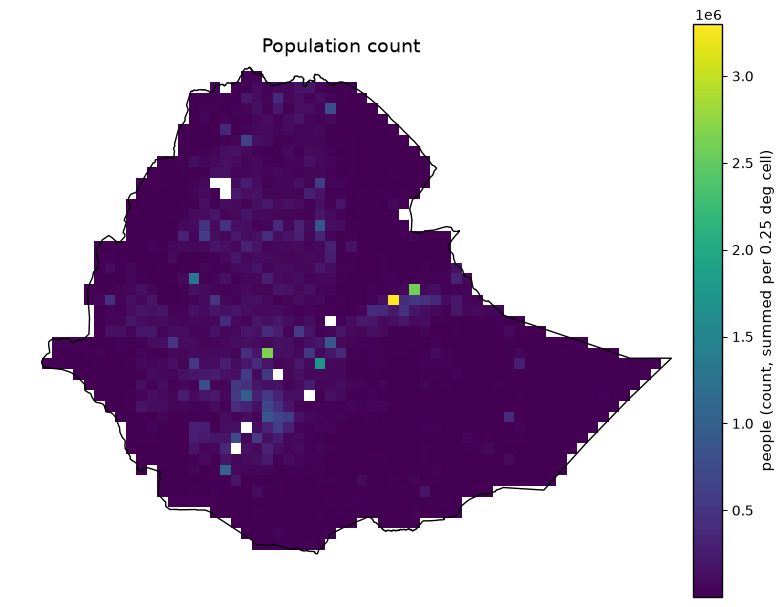

In [ ]:
def plot_population_count():
    """Plot Population Count -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Population count',
        category='Exposure -- population',
        source='WorldPop gridded population count, Ethiopia 2020 (hub.worldpop.org)',
        native_resolution='~100 m',
        native_format='GeoTIFF (count per source pixel)',
        units='people (count, summed per 0.25 deg cell)',
        processing='Extensive count: converted to density, average-resampled, then multiplied by destination cell area to conserve the national total (literal GDAL sum-resampling was found to not be true block-summation).',
        license='CC-BY 4.0',
    )
    describe_and_plot(raw_dir / "ethiopia_population.tif", meta)

plot_population_count()

### Buildings

Buildings  (outputs/exposure_vulnerability/ethiopia_buildings.tif)
  Category:          Exposure -- infrastructure
  Source:            OpenStreetMap building footprints (Geofabrik Ethiopia extract, gis_osm_buildings_a_free_1.shp)
  Native resolution: vector (no fixed grid resolution)
  Native format:     ESRI Shapefile (polygons)
  Units:             count (buildings per 0.25 deg cell)
  License:           ODbL (OpenStreetMap contributors)
  Processing:
    Building centroids binned into 0.25 deg cells (2,554,920 buildings total; 3 empty geometries dropped
    before centroid computation).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=1.69e+03, max=8.11e+04


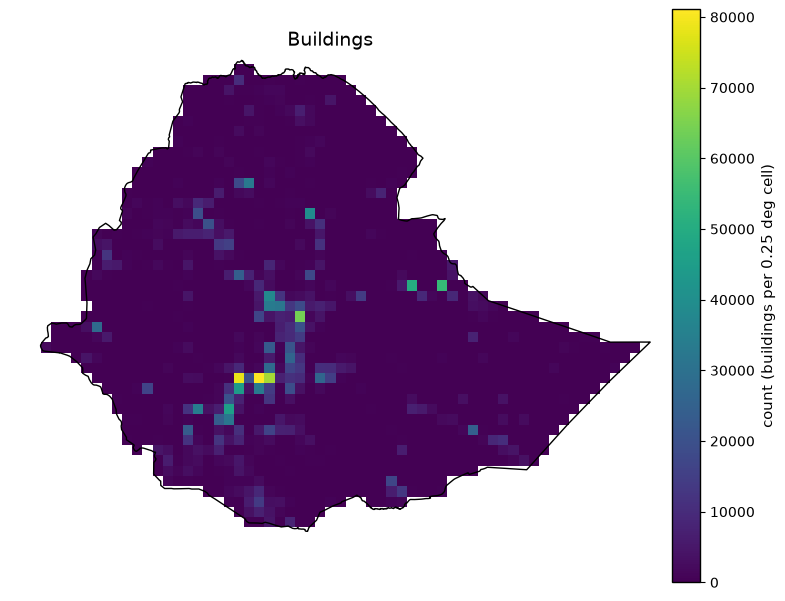

In [23]:
def plot_buildings():
    """Plot Buildings -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Buildings',
        category='Exposure -- infrastructure',
        source='OpenStreetMap building footprints (Geofabrik Ethiopia extract, gis_osm_buildings_a_free_1.shp)',
        native_resolution='vector (no fixed grid resolution)',
        native_format='ESRI Shapefile (polygons)',
        units='count (buildings per 0.25 deg cell)',
        processing='Building centroids binned into 0.25 deg cells (2,554,920 buildings total; 3 empty geometries dropped before centroid computation).',
        license='ODbL (OpenStreetMap contributors)',
    )
    describe_and_plot(raw_dir / "ethiopia_buildings.tif", meta)

plot_buildings()

### Cropland Fraction

Cropland fraction  (outputs/exposure_vulnerability/ethiopia_cropland.tif)
  Category:          Exposure -- agriculture
  Source:            ESA WorldCover 10 m land cover v200 (2021), cropland class (value 40)
  Native resolution: 10 m
  Native format:     Cloud-Optimized GeoTIFF (3x3 deg tiles)
  Units:             fraction of cell classified cropland (0-1)
  License:           CC-BY 4.0
  Processing:
    Exact numpy block-mean of the binary cropland mask (the 3 deg tile grid is an exact 12x multiple of
    0.25 deg, so no destination cell straddles a tile boundary); GDAL's average-resampling was found
    unreliable at this ~20-240x downsampling ratio.
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.185, max=0.99


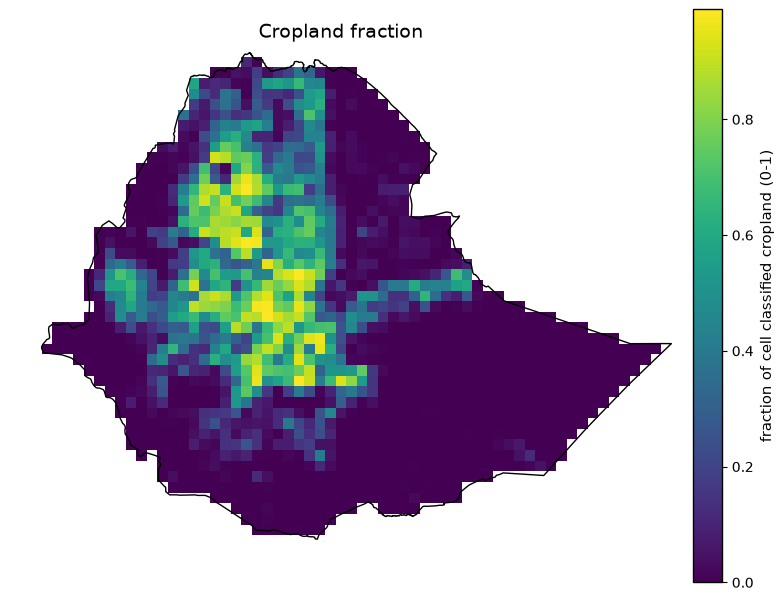

In [ ]:
def plot_cropland_fraction():
    """Plot Cropland fraction -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Cropland fraction',
        category='Exposure -- agriculture',
        source='ESA WorldCover 10 m land cover v200 (2021), cropland class (value 40)',
        native_resolution='10 m',
        native_format='Cloud-Optimized GeoTIFF (3x3 deg tiles)',
        units='fraction of cell classified cropland (0-1)',
        processing="Exact numpy block-mean of the binary cropland mask (the 3 deg tile grid is an exact 12x multiple of 0.25 deg, so no destination cell straddles a tile boundary); GDAL's average-resampling was found unreliable at this ~20-240x downsampling ratio.",
        license='CC-BY 4.0',
    )
    describe_and_plot(raw_dir / "ethiopia_cropland.tif", meta)

plot_cropland_fraction( )

### Livestock -- Cattle

Livestock -- cattle  (outputs/exposure_vulnerability/ethiopia_livestock_cattle.tif)
  Category:          Exposure -- livestock
  Source:            FAO Gridded Livestock of the World v4 (2020), cattle
  Native resolution: 5 arcmin (~10 km), native density head/km^2
  Native format:     GeoTIFF
  Units:             head (count, summed per 0.25 deg cell)
  License:           CC-BY 4.0
  Processing:
    Density x source-pixel area -> head count, then area-weighted-sum resampled to conserve the total
    head count (~87.7M cattle nationally).
  Clipped stats (Ethiopia boundary): n=1477/2820 valid (52.4% coverage), min=0, mean=4.72e+04, max=4.89e+05


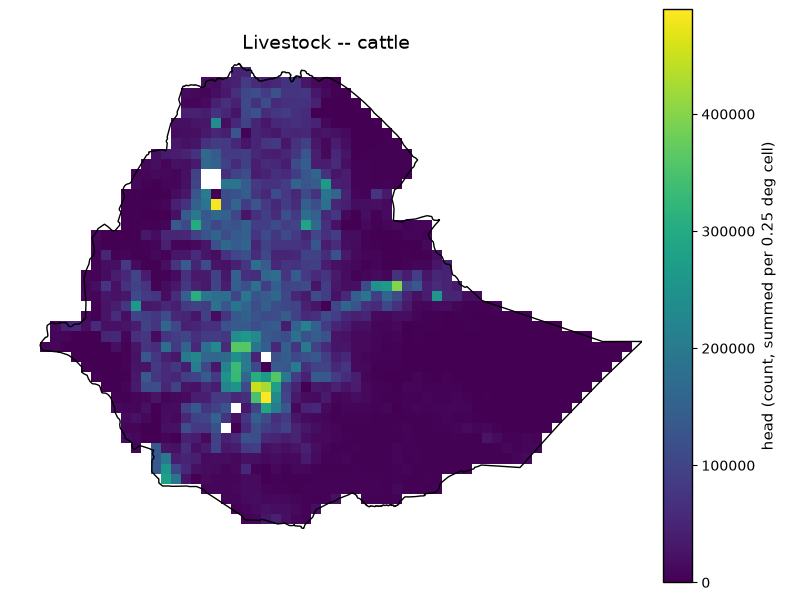

In [25]:
def plot_livestock_cattle():
    """Plot Livestock -- cattle -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Livestock -- cattle',
        category='Exposure -- livestock',
        source='FAO Gridded Livestock of the World v4 (2020), cattle',
        native_resolution='5 arcmin (~10 km), native density head/km^2',
        native_format='GeoTIFF',
        units='head (count, summed per 0.25 deg cell)',
        processing='Density x source-pixel area -> head count, then area-weighted-sum resampled to conserve the total head count (~87.7M cattle nationally).',
        license='CC-BY 4.0',
    )
    describe_and_plot(raw_dir / "ethiopia_livestock_cattle.tif", meta)

plot_livestock_cattle()

### Built-up Surface

Built-up surface  (outputs/exposure_vulnerability/ethiopia_ghs_built.tif)
  Category:          Exposure -- infrastructure (built environment)
  Source:            JRC GHSL GHS-BUILT-S R2023A, 2020 epoch
  Native resolution: 30 arcsec (~1 km), WGS84 global mosaic
  Native format:     GeoTIFF
  Units:             m^2 built-up surface (summed per 0.25 deg cell)
  License:           CC-BY 4.0
  Processing:
    Extensive area quantity; windowed read (global grid is ~924M pixels) then density-then-multiply
    resampling, same conservation approach as population.
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=1.56e+06, max=2.25e+08


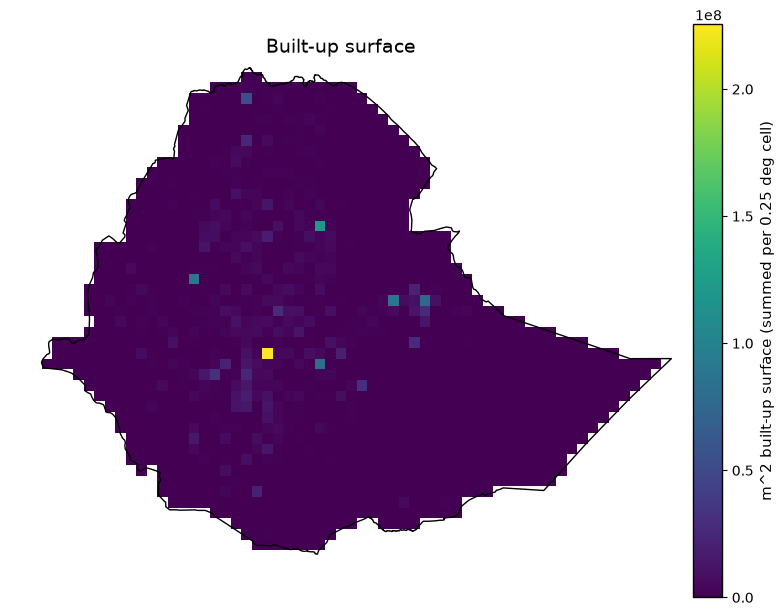

In [26]:
def plot_built_up_surface():
    """Plot Built-up surface -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Built-up surface',
        category='Exposure -- infrastructure (built environment)',
        source='JRC GHSL GHS-BUILT-S R2023A, 2020 epoch',
        native_resolution='30 arcsec (~1 km), WGS84 global mosaic',
        native_format='GeoTIFF',
        units='m^2 built-up surface (summed per 0.25 deg cell)',
        processing='Extensive area quantity; windowed read (global grid is ~924M pixels) then density-then-multiply resampling, same conservation approach as population.',
        license='CC-BY 4.0',
    )
    describe_and_plot(raw_dir / "ethiopia_ghs_built.tif", meta)

plot_built_up_surface()

### Health Facilities

Health facilities  (outputs/exposure_vulnerability/ethiopia_healthsites.tif)
  Category:          Exposure -- infrastructure (also feeds V_wet adaptive capacity)
  Source:            Global Healthsites Mapping Project, via HDX bulk CSV mirror
  Native resolution: point-based (no fixed grid resolution)
  Native format:     CSV (lat/lon points)
  Units:             count (facilities per 0.25 deg cell)
  License:           ODbL (OpenStreetMap contributors, via Global Healthsites Mapping Project)
  Processing:
    Facility points counted per 0.25 deg cell via point-in-cell binning.
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.522, max=129


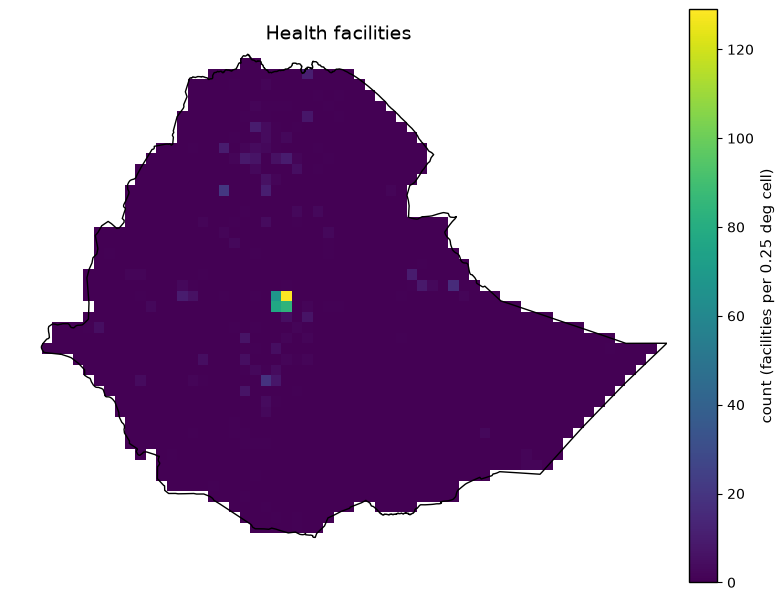

In [27]:
def plot_health_facilities():
    """Plot Health facilities -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Health facilities',
        category='Exposure -- infrastructure (also feeds V_wet adaptive capacity)',
        source='Global Healthsites Mapping Project, via HDX bulk CSV mirror',
        native_resolution='point-based (no fixed grid resolution)',
        native_format='CSV (lat/lon points)',
        units='count (facilities per 0.25 deg cell)',
        processing='Facility points counted per 0.25 deg cell via point-in-cell binning.',
        license='ODbL (OpenStreetMap contributors, via Global Healthsites Mapping Project)',
    )
    describe_and_plot(raw_dir / "ethiopia_healthsites.tif", meta)

plot_health_facilities()

### Roads

Roads  (outputs/exposure_vulnerability/ethiopia_roads.tif)
  Category:          Exposure -- infrastructure
  Source:            OpenStreetMap road network (Geofabrik Ethiopia extract, gis_osm_roads_free_1.shp)
  Native resolution: vector (no fixed grid resolution)
  Native format:     ESRI Shapefile (lines)
  Units:             km (road length per 0.25 deg cell)
  License:           ODbL (OpenStreetMap contributors)
  Processing:
    Geodesic (WGS84 ellipsoid) vector overlay of road lines against the 0.25 deg grid via pyproj -- not
    rasterization (372,412 km total, max density at Addis Ababa as expected).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=244, max=4.05e+03


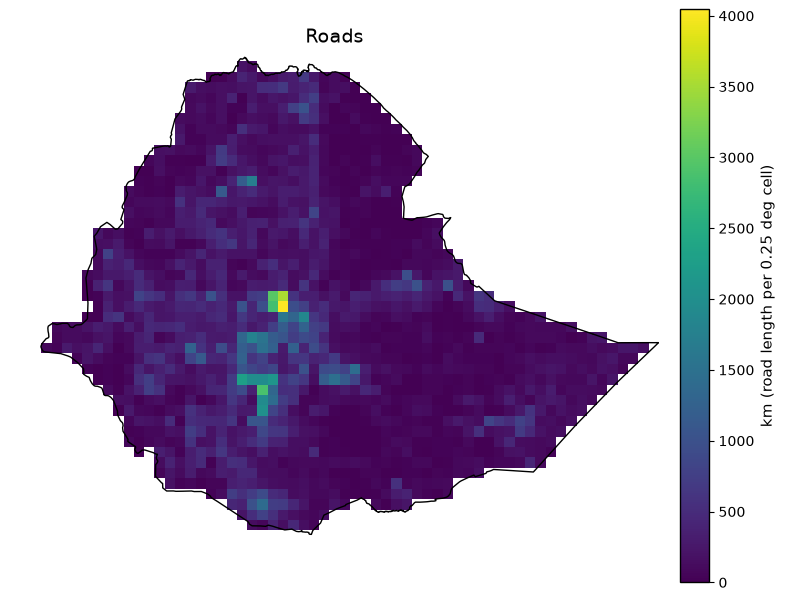

In [28]:
def plot_roads():
    """Plot Roads -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Roads',
        category='Exposure -- infrastructure',
        source='OpenStreetMap road network (Geofabrik Ethiopia extract, gis_osm_roads_free_1.shp)',
        native_resolution='vector (no fixed grid resolution)',
        native_format='ESRI Shapefile (lines)',
        units='km (road length per 0.25 deg cell)',
        processing='Geodesic (WGS84 ellipsoid) vector overlay of road lines against the 0.25 deg grid via pyproj -- not rasterization (372,412 km total, max density at Addis Ababa as expected).',
        license='ODbL (OpenStreetMap contributors)',
    )
    describe_and_plot(raw_dir / "ethiopia_roads.tif", meta)

plot_roads()

### Aridity Index

Aridity index  (outputs/exposure_vulnerability/ethiopia_aridity.tif)
  Category:          Vulnerability -- drought sensitivity
  Source:            CGIAR-CSI Global Aridity Index v3.1
  Native resolution: 30 arcsec (~1 km)
  Native format:     GeoTIFF
  Units:             index (unitless, ~0-1.5+; higher = wetter baseline climate)
  License:           CC-BY 4.0
  Processing:
    Windowed read, mean-resampled to 0.25 deg. Raw file has no embedded GDAL scale tag despite storing
    values x10000 -- a 0.0001 scale factor was applied and verified against known semi-arid climate
    values (domain mean 0.34). Inverted when combined into V_drought (higher AI = less drought-
    sensitive).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0.0551, mean=0.508, max=1.47


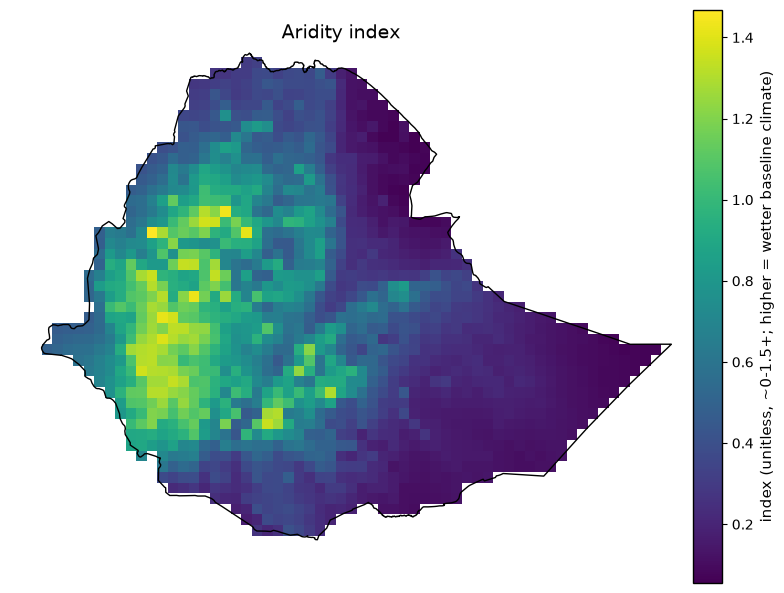

In [29]:
def plot_aridity_index():
    """Plot Aridity index -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Aridity index',
        category='Vulnerability -- drought sensitivity',
        source='CGIAR-CSI Global Aridity Index v3.1',
        native_resolution='30 arcsec (~1 km)',
        native_format='GeoTIFF',
        units='index (unitless, ~0-1.5+; higher = wetter baseline climate)',
        processing='Windowed read, mean-resampled to 0.25 deg. Raw file has no embedded GDAL scale tag despite storing values x10000 -- a 0.0001 scale factor was applied and verified against known semi-arid climate values (domain mean 0.34). Inverted when combined into V_drought (higher AI = less drought-sensitive).',
        license='CC-BY 4.0',
    )
    describe_and_plot(raw_dir / "ethiopia_aridity.tif", meta)

plot_aridity_index()

### Irrigated Area (%)

Irrigated area (%)  (outputs/exposure_vulnerability/ethiopia_irrigation_gmia.tif)
  Category:          Vulnerability -- drought adaptive capacity (also feeds exposure's irrigated/rainfed cropland split)
  Source:            FAO/Bonn Global Map of Irrigation Areas v5
  Native resolution: 5 arcmin (~9 km)
  Native format:     ESRI ASCII grid
  Units:             % of cell area irrigated (0-100)
  License:           CC-BY 4.0
  Processing:
    Mean-resampled to 0.25 deg (domain mean 0.67%, max 88%, consistent with Ethiopia's known very low
    irrigation development). Inverted when combined into V_drought's adaptive-capacity deficit.
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.182, max=26


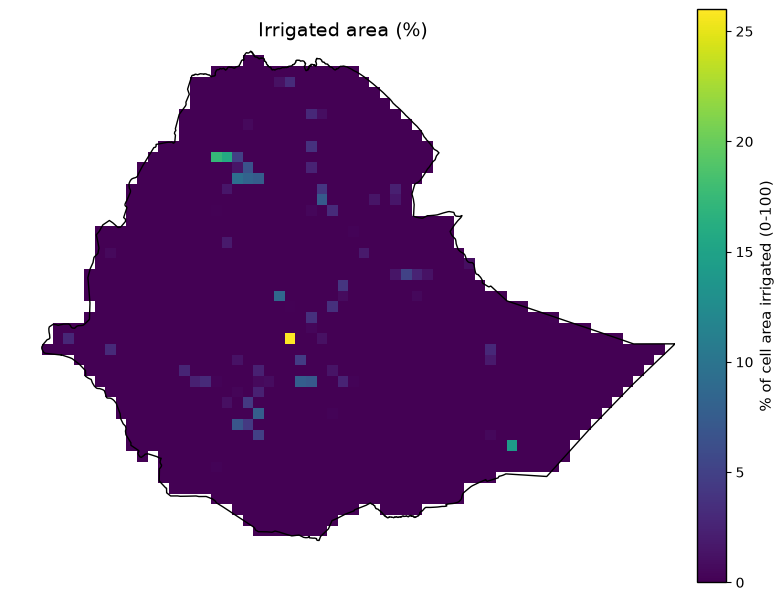

In [30]:
def plot_irrigated_area():
    """Plot Irrigated area (%) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Irrigated area (%)',
        category="Vulnerability -- drought adaptive capacity (also feeds exposure's irrigated/rainfed cropland split)",
        source='FAO/Bonn Global Map of Irrigation Areas v5',
        native_resolution='5 arcmin (~9 km)',
        native_format='ESRI ASCII grid',
        units='% of cell area irrigated (0-100)',
        processing="Mean-resampled to 0.25 deg (domain mean 0.67%, max 88%, consistent with Ethiopia's known very low irrigation development). Inverted when combined into V_drought's adaptive-capacity deficit.",
        license='CC-BY 4.0',
    )
    describe_and_plot(raw_dir / "ethiopia_irrigation_gmia.tif", meta)

plot_irrigated_area()

### Electrification -- No access

Electrification -- no access  (outputs/exposure_vulnerability/ethiopia_gdessa_no_access.tif)
  Category:          Vulnerability -- drought + wet adaptive capacity
  Source:            IIASA/Falchetta et al. GDESSA (population without electricity access), 2020 slice of a 2014-2020 Sub-Saharan-Africa grid
  Native resolution: ~1 km
  Native format:     NetCDF (density, people without access per km^2)
  Units:             people without electricity access (count, summed per 0.25 deg cell)
  License:           CC-BY 4.0
  Processing:
    Density x pixel area -> count, then area-weighted-sum resampled (~80M people nationally). Real
    coverage gap (709/1484 Ethiopia cells valid pre-fill) is nearest-neighbor gap-filled within the
    admin-0 boundary downstream in the vulnerability module -- not in this raw file.
  Clipped stats (Ethiopia boundary): n=709/2820 valid (25.1% coverage), min=775, mean=9.69e+04, max=2.21e+06


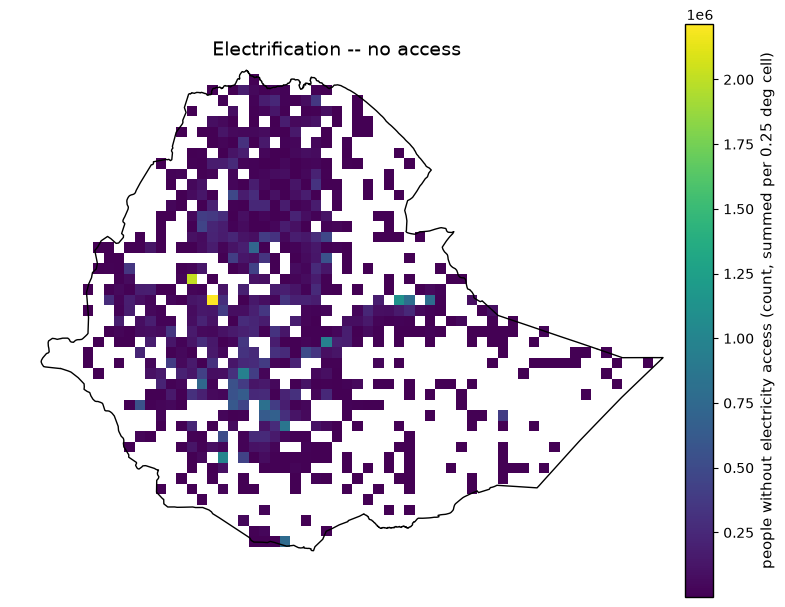

In [31]:
def plot_electrification_no_access():
    """Plot Electrification -- no access -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Electrification -- no access',
        category='Vulnerability -- drought + wet adaptive capacity',
        source='IIASA/Falchetta et al. GDESSA (population without electricity access), 2020 slice of a 2014-2020 Sub-Saharan-Africa grid',
        native_resolution='~1 km',
        native_format='NetCDF (density, people without access per km^2)',
        units='people without electricity access (count, summed per 0.25 deg cell)',
        processing='Density x pixel area -> count, then area-weighted-sum resampled (~80M people nationally). Real coverage gap (709/1484 Ethiopia cells valid pre-fill) is nearest-neighbor gap-filled within the admin-0 boundary downstream in the vulnerability module -- not in this raw file.',
        license='CC-BY 4.0',
    )
    describe_and_plot(raw_dir / "ethiopia_gdessa_no_access.tif", meta)

plot_electrification_no_access()

### Elevation

Elevation  (outputs/exposure_vulnerability/ethiopia_elevation.tif)
  Category:          Vulnerability -- wet sensitivity
  Source:            NOAA ETOPO 2022 global relief model
  Native resolution: 30 arcsec (~900 m)
  Native format:     GeoTIFF (streamed via HTTP range requests, /vsicurl/)
  Units:             meters (mean-aggregated per 0.25 deg cell)
  License:           Public domain (NOAA/NCEI, U.S. Government work; not for navigational use)
  Processing:
    Windowed read, mean-aggregated to 0.25 deg. Low elevation = low-lying = more wet-vulnerable
    (inverted in V_wet). Includes real Red Sea bathymetry in the domain's NE corner (outside Ethiopia).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=-124, mean=1.26e+03, max=4.03e+03


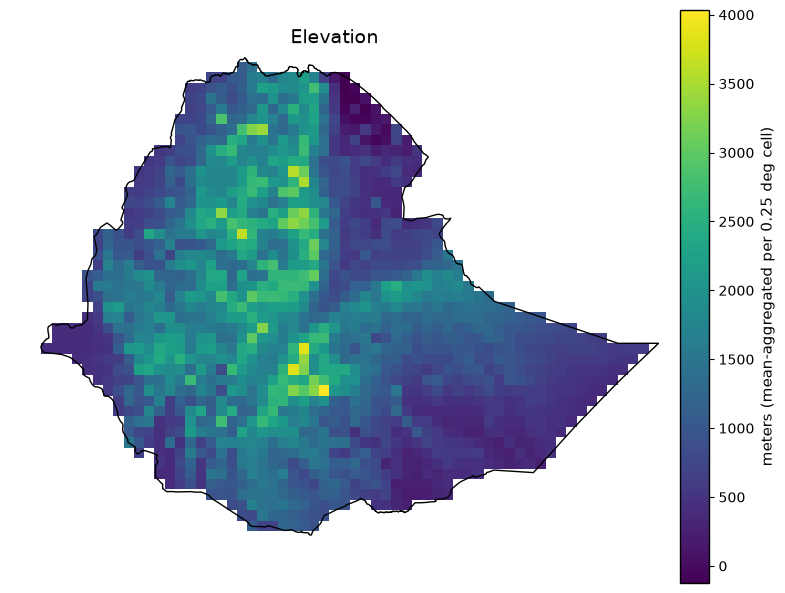

In [32]:
def plot_elevation():
    """Plot Elevation -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Elevation',
        category='Vulnerability -- wet sensitivity',
        source='NOAA ETOPO 2022 global relief model',
        native_resolution='30 arcsec (~900 m)',
        native_format='GeoTIFF (streamed via HTTP range requests, /vsicurl/)',
        units='meters (mean-aggregated per 0.25 deg cell)',
        processing="Windowed read, mean-aggregated to 0.25 deg. Low elevation = low-lying = more wet-vulnerable (inverted in V_wet). Includes real Red Sea bathymetry in the domain's NE corner (outside Ethiopia).",
        license='Public domain (NOAA/NCEI, U.S. Government work; not for navigational use)',
    )
    describe_and_plot(raw_dir / "ethiopia_elevation.tif", meta)

plot_elevation()

### Slope

Slope  (outputs/exposure_vulnerability/ethiopia_slope.tif)
  Category:          Vulnerability -- wet sensitivity
  Source:            Derived from NOAA ETOPO 2022 (same source file as elevation)
  Native resolution: 30 arcsec (~900 m)
  Native format:     Computed, not separately distributed
  Units:             degrees (mean-aggregated per 0.25 deg cell)
  License:           Public domain (NOAA/NCEI)
  Processing:
    Central-difference gradient at native 30-arcsec resolution using true per-latitude meter spacing,
    then mean-aggregated to 0.25 deg. Flat terrain (low slope) = poor drainage = more wet-vulnerable
    (inverted in V_wet). An explicit simplification of Topographic Wetness Index -- no flow-accumulation
    tooling (richdem/pysheds/whitebox) was available for a full TWI.
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=2.89, max=20.4


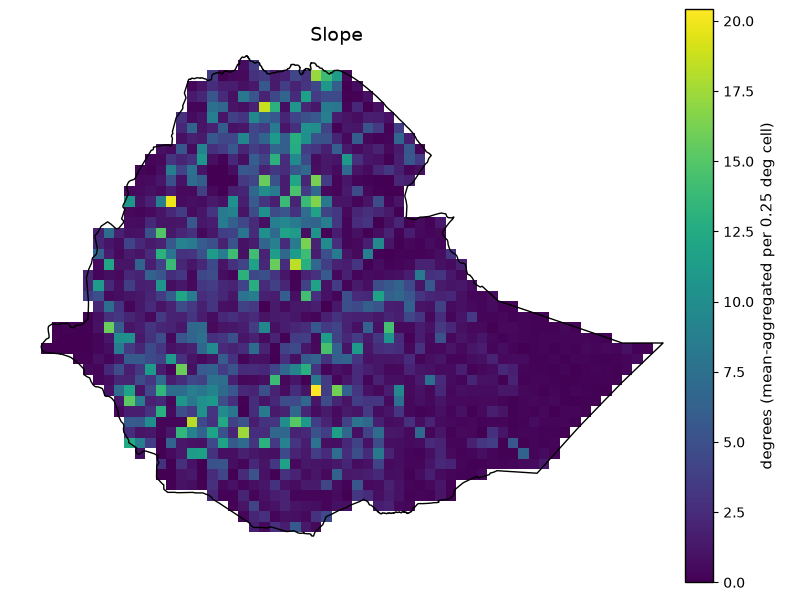

In [33]:
def plot_slope():
    """Plot Slope -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Slope',
        category='Vulnerability -- wet sensitivity',
        source='Derived from NOAA ETOPO 2022 (same source file as elevation)',
        native_resolution='30 arcsec (~900 m)',
        native_format='Computed, not separately distributed',
        units='degrees (mean-aggregated per 0.25 deg cell)',
        processing='Central-difference gradient at native 30-arcsec resolution using true per-latitude meter spacing, then mean-aggregated to 0.25 deg. Flat terrain (low slope) = poor drainage = more wet-vulnerable (inverted in V_wet). An explicit simplification of Topographic Wetness Index -- no flow-accumulation tooling (richdem/pysheds/whitebox) was available for a full TWI.',
        license='Public domain (NOAA/NCEI)',
    )
    describe_and_plot(raw_dir / "ethiopia_slope.tif", meta)

plot_slope()

### Soil Clay Content

Soil clay content  (outputs/exposure_vulnerability/ethiopia_soil_clay.tif)
  Category:          Vulnerability -- wet sensitivity
  Source:            ISRIC SoilGrids 2.0, topsoil (0-5 cm) mean clay content
  Native resolution: 250 m
  Native format:     Cloud-Optimized GeoTIFF via WebDAV/VRT (native CRS: Interrupted Goode Homolosine)
  Units:             % clay content (0-100)
  License:           CC-BY 4.0
  Processing:
    Reprojected via a rasterio WarpedVRT; documented g/kg x10 convention applied (divide by 10 for
    percent), verified against known global topsoil averages (~24.5% mean). High clay = poor
    infiltration = more wet-vulnerable (direct in V_wet).
  Clipped stats (Ethiopia boundary): n=1480/2820 valid (52.5% coverage), min=17.5, mean=33.2, max=53.6


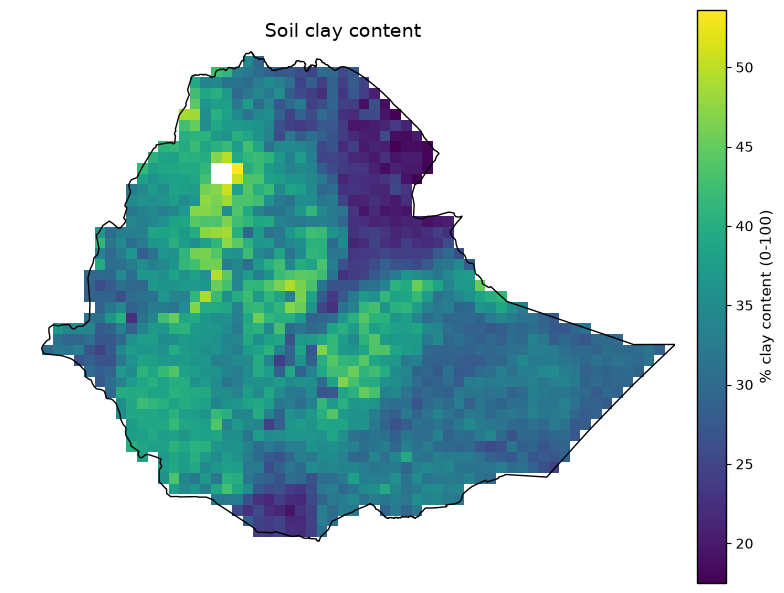

In [34]:
def plot_soil_clay_content():
    """Plot Soil clay content -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Soil clay content',
        category='Vulnerability -- wet sensitivity',
        source='ISRIC SoilGrids 2.0, topsoil (0-5 cm) mean clay content',
        native_resolution='250 m',
        native_format='Cloud-Optimized GeoTIFF via WebDAV/VRT (native CRS: Interrupted Goode Homolosine)',
        units='% clay content (0-100)',
        processing='Reprojected via a rasterio WarpedVRT; documented g/kg x10 convention applied (divide by 10 for percent), verified against known global topsoil averages (~24.5% mean). High clay = poor infiltration = more wet-vulnerable (direct in V_wet).',
        license='CC-BY 4.0',
    )
    describe_and_plot(raw_dir / "ethiopia_soil_clay.tif", meta)

plot_soil_clay_content()

### River / Water-body distance

River / water-body distance  (outputs/exposure_vulnerability/ethiopia_river_distance.tif)
  Category:          Vulnerability -- wet sensitivity
  Source:            OpenStreetMap waterways + water bodies (Geofabrik Ethiopia extract, gis_osm_waterways_free_1.shp + gis_osm_water_a_free_1.shp)
  Native resolution: vector (no fixed grid resolution)
  Native format:     ESRI Shapefile (lines + polygons)
  Units:             km (distance from cell centroid to nearest river/water body)
  License:           ODbL (OpenStreetMap contributors)
  Processing:
    Nearest-feature distance via geopandas sjoin_nearest in a local Azimuthal Equidistant projection
    centered on Ethiopia (lat_0=9, lon_0=40), not UTM (Ethiopia spans multiple UTM zones). Short
    distance = more wet-vulnerable (inverted in V_wet). OSM extract is clipped to Ethiopia's territory,
    slightly overestimating distance for a handful of border cells near cross-border rivers.
  Clipped stats (Ethiopia boundary): n=1484/2820 val

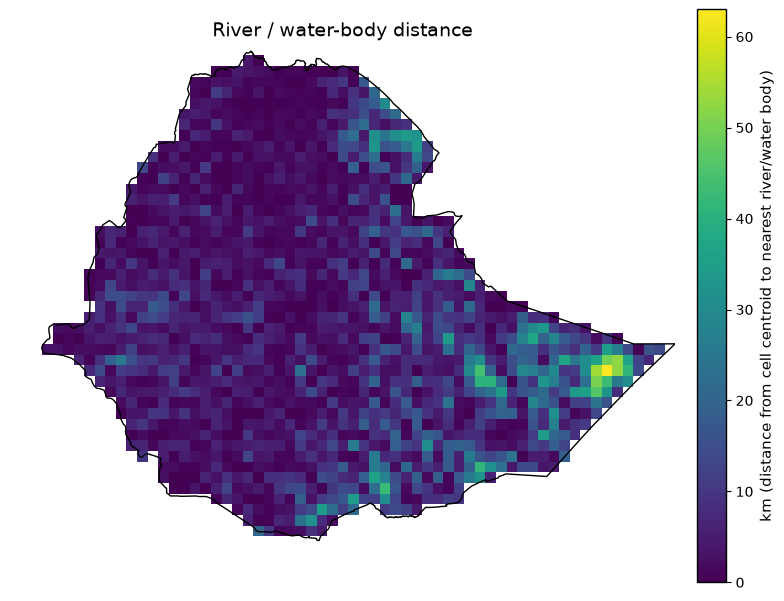

In [35]:
def plot_river_water_body_distance():
    """Plot River / water-body distance -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='River / water-body distance',
        category='Vulnerability -- wet sensitivity',
        source='OpenStreetMap waterways + water bodies (Geofabrik Ethiopia extract, gis_osm_waterways_free_1.shp + gis_osm_water_a_free_1.shp)',
        native_resolution='vector (no fixed grid resolution)',
        native_format='ESRI Shapefile (lines + polygons)',
        units='km (distance from cell centroid to nearest river/water body)',
        processing="Nearest-feature distance via geopandas sjoin_nearest in a local Azimuthal Equidistant projection centered on Ethiopia (lat_0=9, lon_0=40), not UTM (Ethiopia spans multiple UTM zones). Short distance = more wet-vulnerable (inverted in V_wet). OSM extract is clipped to Ethiopia's territory, slightly overestimating distance for a handful of border cells near cross-border rivers.",
        license='ODbL (OpenStreetMap contributors)',
    )
    describe_and_plot(raw_dir / "ethiopia_river_distance.tif", meta)

plot_river_water_body_distance()

### Relative Wealth Index

Relative Wealth Index  (outputs/exposure_vulnerability/ethiopia_poverty_rwi.tif)
  Category:          Vulnerability -- drought + wet sensitivity
  Source:            Meta Relative Wealth Index (Data for Good, via HDX)
  Native resolution: ~2.4 km (point resolution)
  Native format:     CSV (lat/lon points)
  Units:             index (unitless, roughly -1 to +1, centered near 0; higher = wealthier)
  License:           CC-BY 4.0 (Meta Data for Good)
  Processing:
    Mean of points falling in each 0.25 deg cell (domain range -1.16 to 0.17, mean -0.46). Small real
    gap (54/1484 Ethiopia cells) nearest-neighbor gap-filled downstream. Higher RWI = wealthier = LESS
    vulnerable (inverted when combined into V_drought/V_wet).
  Clipped stats (Ethiopia boundary): n=1430/2820 valid (50.7% coverage), min=-1.06, mean=-0.458, max=0.168


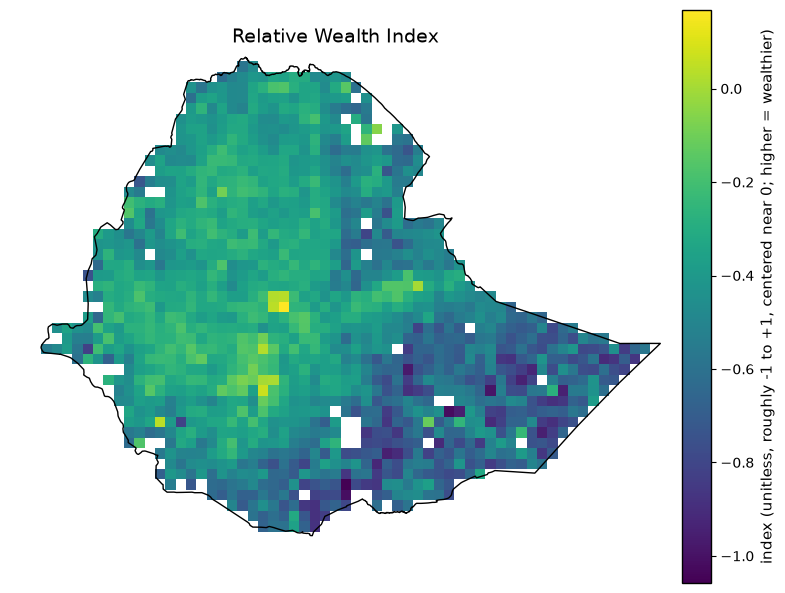

In [36]:
def plot_relative_wealth_index():
    """Plot Relative Wealth Index -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Relative Wealth Index',
        category='Vulnerability -- drought + wet sensitivity',
        source='Meta Relative Wealth Index (Data for Good, via HDX)',
        native_resolution='~2.4 km (point resolution)',
        native_format='CSV (lat/lon points)',
        units='index (unitless, roughly -1 to +1, centered near 0; higher = wealthier)',
        processing='Mean of points falling in each 0.25 deg cell (domain range -1.16 to 0.17, mean -0.46). Small real gap (54/1484 Ethiopia cells) nearest-neighbor gap-filled downstream. Higher RWI = wealthier = LESS vulnerable (inverted when combined into V_drought/V_wet).',
        license='CC-BY 4.0 (Meta Data for Good)',
    )
    describe_and_plot(raw_dir / "ethiopia_poverty_rwi.tif", meta)

plot_relative_wealth_index()

## Exposure layers (absolute + normalized) -- outputs/exposure/

### Population (normalized)

Population (normalized)  (outputs/exposure/ethiopia_population_normalized.tif)
  Category:          Exposure -- population
  Source:            Normalized from ethiopia_population.tif
  Native resolution: 0.25 deg analysis grid (source: ~100 m)
  Native format:     GeoTIFF
  Units:             normalized index (0-1, robust 5th/95th-percentile of the absolute layer, domain-wide)
  License:           CC-BY 4.0 (WorldPop)
  Processing:
    robust_percentile_normalize(p_low=5, p_high=95); small gap (15/1484 Ethiopia cells) nearest-neighbor
    gap-filled first.
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.194, max=1


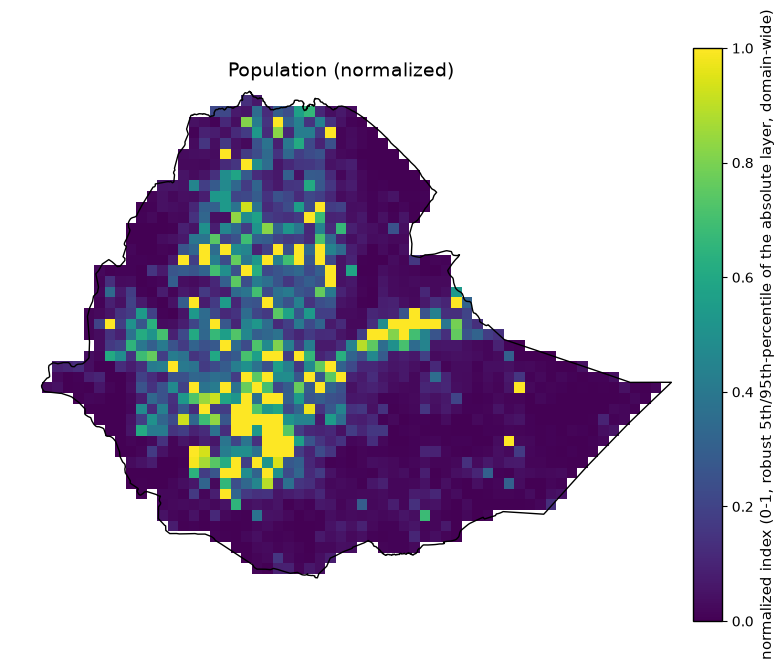

In [37]:
def plot_population_normalized():
    """Plot Population (normalized) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Population (normalized)',
        category='Exposure -- population',
        source='Normalized from ethiopia_population.tif',
        native_resolution='0.25 deg analysis grid (source: ~100 m)',
        native_format='GeoTIFF',
        units='normalized index (0-1, robust 5th/95th-percentile of the absolute layer, domain-wide)',
        processing='robust_percentile_normalize(p_low=5, p_high=95); small gap (15/1484 Ethiopia cells) nearest-neighbor gap-filled first.',
        license='CC-BY 4.0 (WorldPop)',
    )
    describe_and_plot(exposure_dir / "ethiopia_population_normalized.tif", meta)

plot_population_normalized()

### Buildings (normalized)

Buildings (normalized)  (outputs/exposure/ethiopia_buildings_normalized.tif)
  Category:          Exposure -- infrastructure
  Source:            Normalized from ethiopia_buildings.tif
  Native resolution: 0.25 deg analysis grid
  Native format:     GeoTIFF
  Units:             normalized index (0-1, robust 5th/95th-percentile, domain-wide)
  License:           ODbL (OpenStreetMap contributors)
  Processing:
    robust_percentile_normalize(p_low=5, p_high=95).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.166, max=1


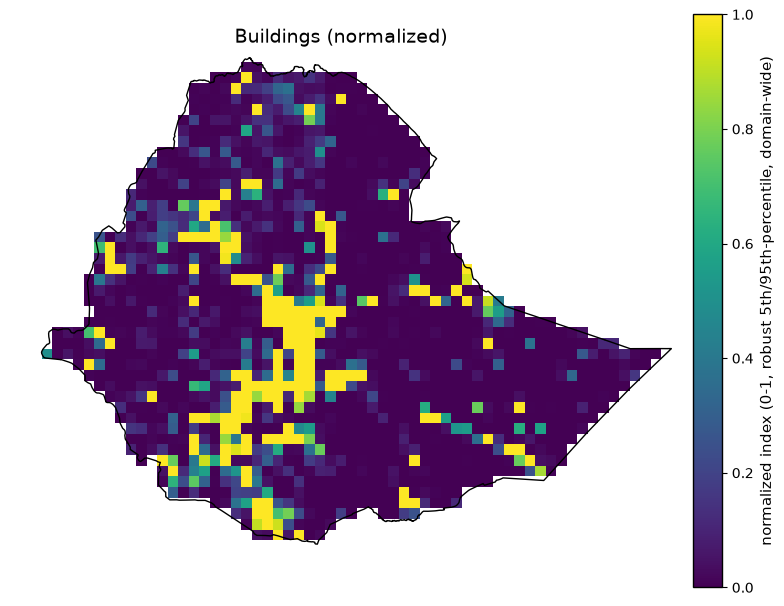

In [38]:
def plot_buildings_normalized():
    """Plot Buildings (normalized) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Buildings (normalized)',
        category='Exposure -- infrastructure',
        source='Normalized from ethiopia_buildings.tif',
        native_resolution='0.25 deg analysis grid',
        native_format='GeoTIFF',
        units='normalized index (0-1, robust 5th/95th-percentile, domain-wide)',
        processing='robust_percentile_normalize(p_low=5, p_high=95).',
        license='ODbL (OpenStreetMap contributors)',
    )
    describe_and_plot(exposure_dir / "ethiopia_buildings_normalized.tif", meta)

plot_buildings_normalized()

### Built-up surface (normalized)

Built-up surface (normalized)  (outputs/exposure/ethiopia_built_up_normalized.tif)
  Category:          Exposure -- infrastructure
  Source:            Normalized from ethiopia_ghs_built.tif
  Native resolution: 0.25 deg analysis grid (source: ~1 km)
  Native format:     GeoTIFF
  Units:             normalized index (0-1, robust 5th/95th-percentile, domain-wide)
  License:           CC-BY 4.0 (JRC GHSL)
  Processing:
    robust_percentile_normalize(p_low=5, p_high=95).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.164, max=1


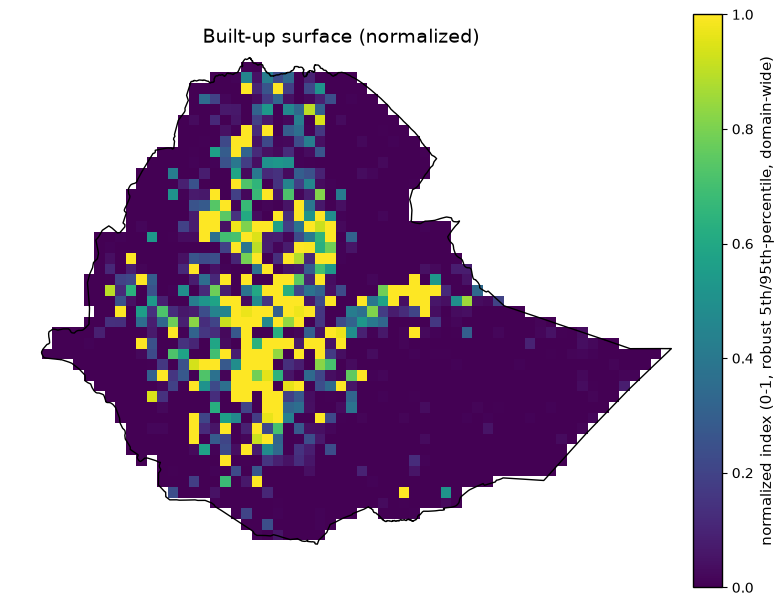

In [39]:
def plot_built_up_surface_normalized():
    """Plot Built-up surface (normalized) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Built-up surface (normalized)',
        category='Exposure -- infrastructure',
        source='Normalized from ethiopia_ghs_built.tif',
        native_resolution='0.25 deg analysis grid (source: ~1 km)',
        native_format='GeoTIFF',
        units='normalized index (0-1, robust 5th/95th-percentile, domain-wide)',
        processing='robust_percentile_normalize(p_low=5, p_high=95).',
        license='CC-BY 4.0 (JRC GHSL)',
    )
    describe_and_plot(exposure_dir / "ethiopia_built_up_normalized.tif", meta)

plot_built_up_surface_normalized()

### Roads (normalized)

Roads (normalized)  (outputs/exposure/ethiopia_roads_normalized.tif)
  Category:          Exposure -- infrastructure
  Source:            Normalized from ethiopia_roads.tif
  Native resolution: 0.25 deg analysis grid
  Native format:     GeoTIFF
  Units:             normalized index (0-1, robust 5th/95th-percentile, domain-wide)
  License:           ODbL (OpenStreetMap contributors)
  Processing:
    robust_percentile_normalize(p_low=5, p_high=95).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.365, max=1


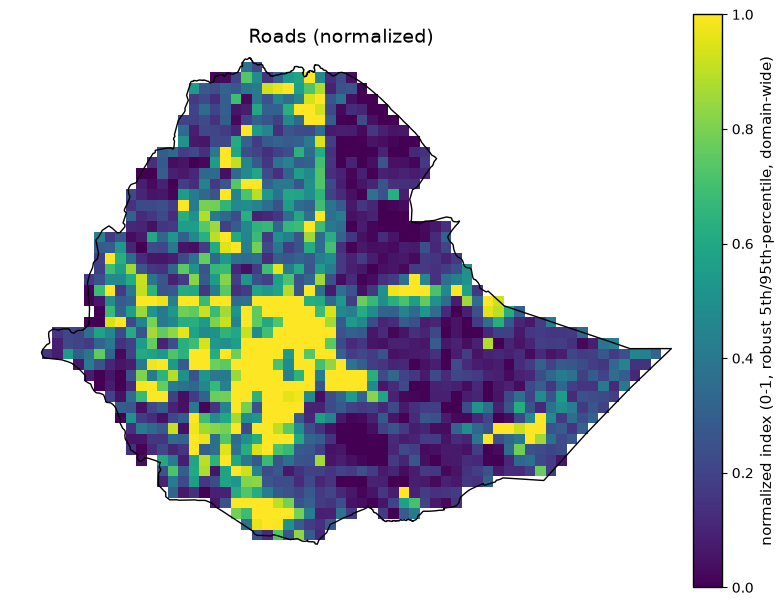

In [40]:
def plot_roads_normalized():
    """Plot Roads (normalized) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Roads (normalized)',
        category='Exposure -- infrastructure',
        source='Normalized from ethiopia_roads.tif',
        native_resolution='0.25 deg analysis grid',
        native_format='GeoTIFF',
        units='normalized index (0-1, robust 5th/95th-percentile, domain-wide)',
        processing='robust_percentile_normalize(p_low=5, p_high=95).',
        license='ODbL (OpenStreetMap contributors)',
    )
    describe_and_plot(exposure_dir / "ethiopia_roads_normalized.tif", meta)

plot_roads_normalized()

### Livestock -- cattle (normalized)

Livestock -- cattle (normalized)  (outputs/exposure/ethiopia_livestock_cattle_normalized.tif)
  Category:          Exposure -- livestock
  Source:            Normalized from ethiopia_livestock_cattle.tif
  Native resolution: 0.25 deg analysis grid (source: ~10 km)
  Native format:     GeoTIFF
  Units:             normalized index (0-1, robust 5th/95th-percentile, domain-wide)
  License:           CC-BY 4.0 (FAO GLW4)
  Processing:
    robust_percentile_normalize(p_low=5, p_high=95).
  Clipped stats (Ethiopia boundary): n=1477/2820 valid (52.4% coverage), min=0, mean=0.295, max=1


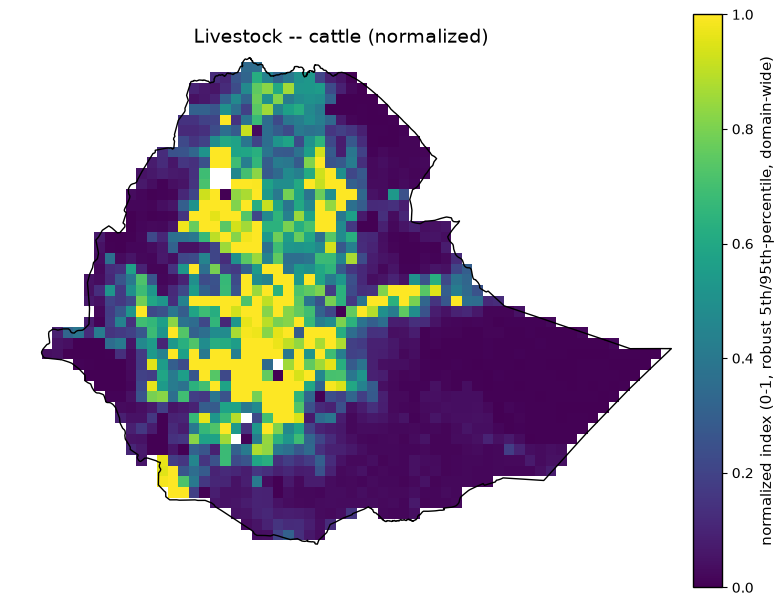

In [41]:
def plot_livestock_cattle_normalized():
    """Plot Livestock -- cattle (normalized) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Livestock -- cattle (normalized)',
        category='Exposure -- livestock',
        source='Normalized from ethiopia_livestock_cattle.tif',
        native_resolution='0.25 deg analysis grid (source: ~10 km)',
        native_format='GeoTIFF',
        units='normalized index (0-1, robust 5th/95th-percentile, domain-wide)',
        processing='robust_percentile_normalize(p_low=5, p_high=95).',
        license='CC-BY 4.0 (FAO GLW4)',
    )
    describe_and_plot(exposure_dir / "ethiopia_livestock_cattle_normalized.tif", meta)

plot_livestock_cattle_normalized()

### Health facilities (normalized)

Health facilities (normalized)  (outputs/exposure/ethiopia_healthsites_normalized.tif)
  Category:          Exposure -- infrastructure
  Source:            Normalized from ethiopia_healthsites.tif
  Native resolution: 0.25 deg analysis grid
  Native format:     GeoTIFF
  Units:             normalized index (0-1, robust 0th/99th-percentile override, domain-wide)
  License:           ODbL (Global Healthsites Mapping Project)
  Processing:
    robust_percentile_normalize(p_low=0, p_high=99) -- the domain-wide default (5/95) degenerates to a
    flat 0.5 because 95.03% of cells are exactly zero (only towns/cities have a mapped facility); the
    0/99 override keeps zero-vs-any-facility distinguishable.
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.045, max=1


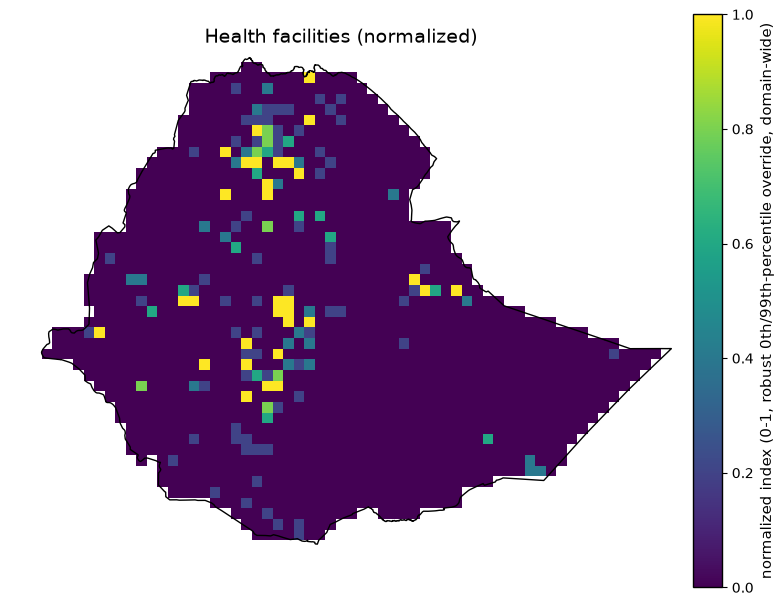

In [42]:
def plot_health_facilities_normalized():
    """Plot Health facilities (normalized) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Health facilities (normalized)',
        category='Exposure -- infrastructure',
        source='Normalized from ethiopia_healthsites.tif',
        native_resolution='0.25 deg analysis grid',
        native_format='GeoTIFF',
        units='normalized index (0-1, robust 0th/99th-percentile override, domain-wide)',
        processing='robust_percentile_normalize(p_low=0, p_high=99) -- the domain-wide default (5/95) degenerates to a flat 0.5 because 95.03% of cells are exactly zero (only towns/cities have a mapped facility); the 0/99 override keeps zero-vs-any-facility distinguishable.',
        license='ODbL (Global Healthsites Mapping Project)',
    )
    describe_and_plot(exposure_dir / "ethiopia_healthsites_normalized.tif", meta)

plot_health_facilities_normalized()

### Cropland -- total (normalized)

Cropland -- total (normalized)  (outputs/exposure/ethiopia_cropland_total_normalized.tif)
  Category:          Exposure -- agriculture
  Source:            Normalized from ethiopia_cropland.tif
  Native resolution: 0.25 deg analysis grid (source: 10 m)
  Native format:     GeoTIFF
  Units:             normalized index (0-1, robust 5th/95th-percentile, domain-wide)
  License:           CC-BY 4.0 (ESA WorldCover)
  Processing:
    robust_percentile_normalize(p_low=5, p_high=95).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.218, max=1


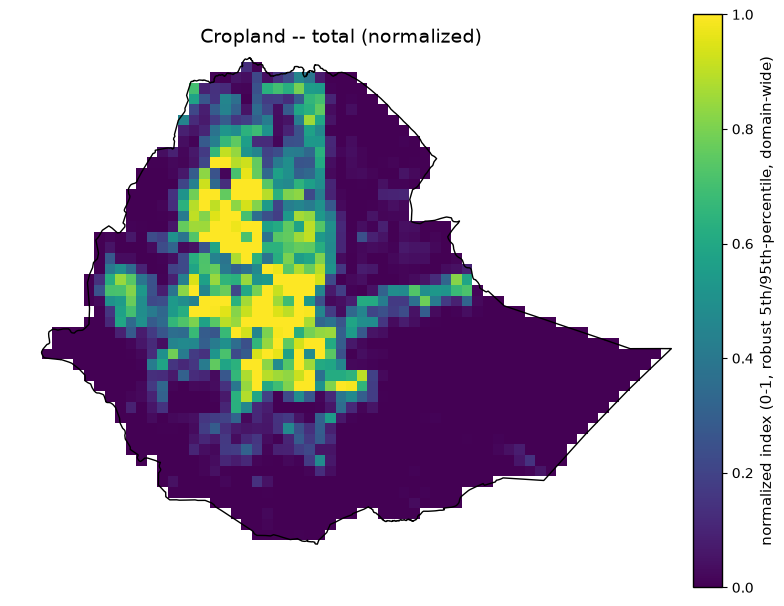

In [43]:
def plot_cropland_total_normalized():
    """Plot Cropland -- total (normalized) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Cropland -- total (normalized)',
        category='Exposure -- agriculture',
        source='Normalized from ethiopia_cropland.tif',
        native_resolution='0.25 deg analysis grid (source: 10 m)',
        native_format='GeoTIFF',
        units='normalized index (0-1, robust 5th/95th-percentile, domain-wide)',
        processing='robust_percentile_normalize(p_low=5, p_high=95).',
        license='CC-BY 4.0 (ESA WorldCover)',
    )
    describe_and_plot(exposure_dir / "ethiopia_cropland_total_normalized.tif", meta)

plot_cropland_total_normalized()

### Cropland -- irrigated (absolute)

Cropland -- irrigated (absolute)  (outputs/exposure/ethiopia_cropland_irrigated_absolute.tif)
  Category:          Exposure -- agriculture
  Source:            Derived: ethiopia_cropland.tif x (ethiopia_irrigation_gmia.tif / 100)
  Native resolution: 0.25 deg analysis grid
  Native format:     GeoTIFF
  Units:             fraction of cell (0-1)
  License:           CC-BY 4.0 (ESA WorldCover + FAO/Bonn GMIA v5)
  Processing:
    cropland_fraction * (irrigation_percent / 100), computed at the 0.25 deg grid (both inputs already
    on this grid).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.00094, max=0.162


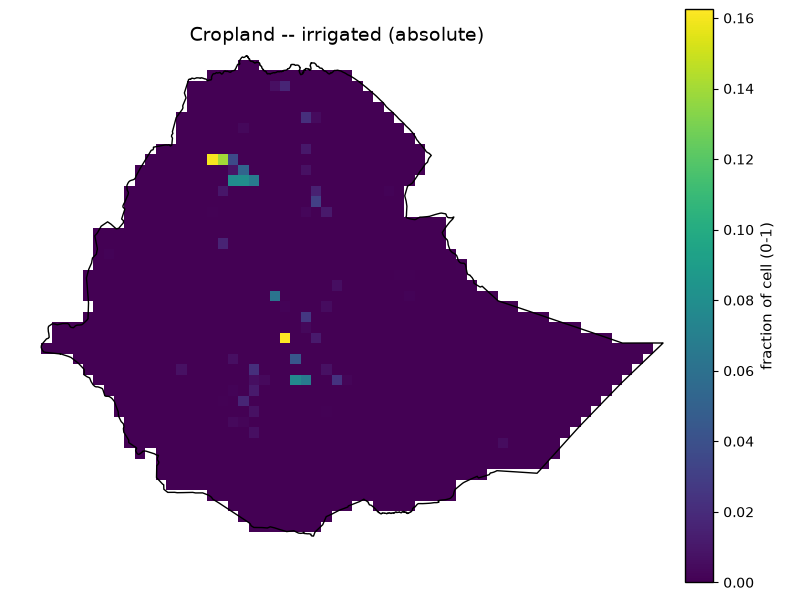

In [44]:
def plot_cropland_irrigated_absolute():
    """Plot Cropland -- irrigated (absolute) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Cropland -- irrigated (absolute)',
        category='Exposure -- agriculture',
        source='Derived: ethiopia_cropland.tif x (ethiopia_irrigation_gmia.tif / 100)',
        native_resolution='0.25 deg analysis grid',
        native_format='GeoTIFF',
        units='fraction of cell (0-1)',
        processing='cropland_fraction * (irrigation_percent / 100), computed at the 0.25 deg grid (both inputs already on this grid).',
        license='CC-BY 4.0 (ESA WorldCover + FAO/Bonn GMIA v5)',
    )
    describe_and_plot(exposure_dir / "ethiopia_cropland_irrigated_absolute.tif", meta)

plot_cropland_irrigated_absolute()

### Cropland -- irrigated (normalized)

Cropland -- irrigated (normalized)  (outputs/exposure/ethiopia_cropland_irrigated_normalized.tif)
  Category:          Exposure -- agriculture
  Source:            Normalized from ethiopia_cropland_irrigated_absolute.tif
  Native resolution: 0.25 deg analysis grid
  Native format:     GeoTIFF
  Units:             normalized index (0-1, robust 5th/95th-percentile, domain-wide)
  License:           CC-BY 4.0
  Processing:
    robust_percentile_normalize(p_low=5, p_high=95).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.0437, max=1


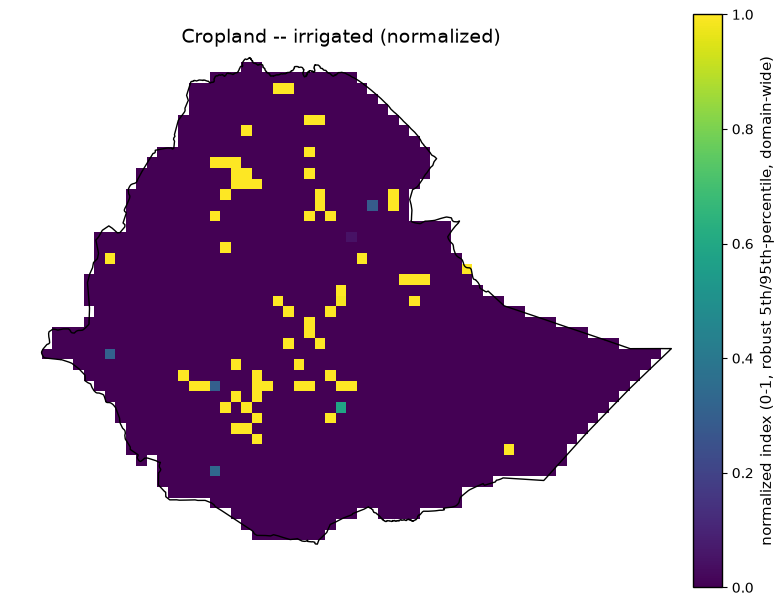

In [45]:
def plot_cropland_irrigated_normalized():
    """Plot Cropland -- irrigated (normalized) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Cropland -- irrigated (normalized)',
        category='Exposure -- agriculture',
        source='Normalized from ethiopia_cropland_irrigated_absolute.tif',
        native_resolution='0.25 deg analysis grid',
        native_format='GeoTIFF',
        units='normalized index (0-1, robust 5th/95th-percentile, domain-wide)',
        processing='robust_percentile_normalize(p_low=5, p_high=95).',
        license='CC-BY 4.0',
    )
    describe_and_plot(exposure_dir / "ethiopia_cropland_irrigated_normalized.tif", meta)

plot_cropland_irrigated_normalized()

### Cropland -- rainfed (absolute)

Cropland -- rainfed (absolute)  (outputs/exposure/ethiopia_cropland_rainfed_absolute.tif)
  Category:          Exposure -- agriculture
  Source:            Derived: ethiopia_cropland.tif x (1 - ethiopia_irrigation_gmia.tif / 100)
  Native resolution: 0.25 deg analysis grid
  Native format:     GeoTIFF
  Units:             fraction of cell (0-1)
  License:           CC-BY 4.0 (ESA WorldCover + FAO/Bonn GMIA v5)
  Processing:
    cropland_fraction * (1 - irrigation_percent / 100), the complement of the irrigated split.
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.184, max=0.99


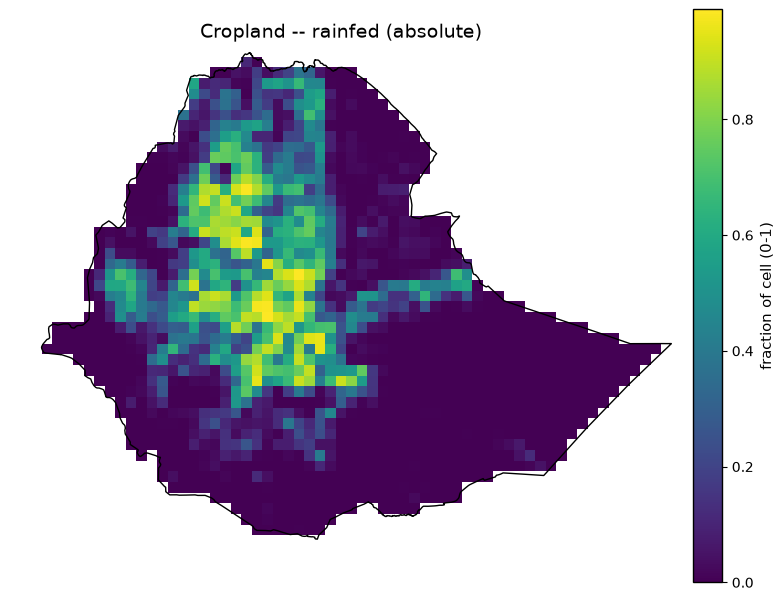

In [46]:
def plot_cropland_rainfed_absolute():
    """Plot Cropland -- rainfed (absolute) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Cropland -- rainfed (absolute)',
        category='Exposure -- agriculture',
        source='Derived: ethiopia_cropland.tif x (1 - ethiopia_irrigation_gmia.tif / 100)',
        native_resolution='0.25 deg analysis grid',
        native_format='GeoTIFF',
        units='fraction of cell (0-1)',
        processing='cropland_fraction * (1 - irrigation_percent / 100), the complement of the irrigated split.',
        license='CC-BY 4.0 (ESA WorldCover + FAO/Bonn GMIA v5)',
    )
    describe_and_plot(exposure_dir / "ethiopia_cropland_rainfed_absolute.tif", meta)

plot_cropland_rainfed_absolute()

### Cropland -- rainfed (normalized)

Cropland -- rainfed (normalized)  (outputs/exposure/ethiopia_cropland_rainfed_normalized.tif)
  Category:          Exposure -- agriculture
  Source:            Normalized from ethiopia_cropland_rainfed_absolute.tif
  Native resolution: 0.25 deg analysis grid
  Native format:     GeoTIFF
  Units:             normalized index (0-1, robust 5th/95th-percentile, domain-wide)
  License:           CC-BY 4.0
  Processing:
    robust_percentile_normalize(p_low=5, p_high=95).
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0, mean=0.223, max=1


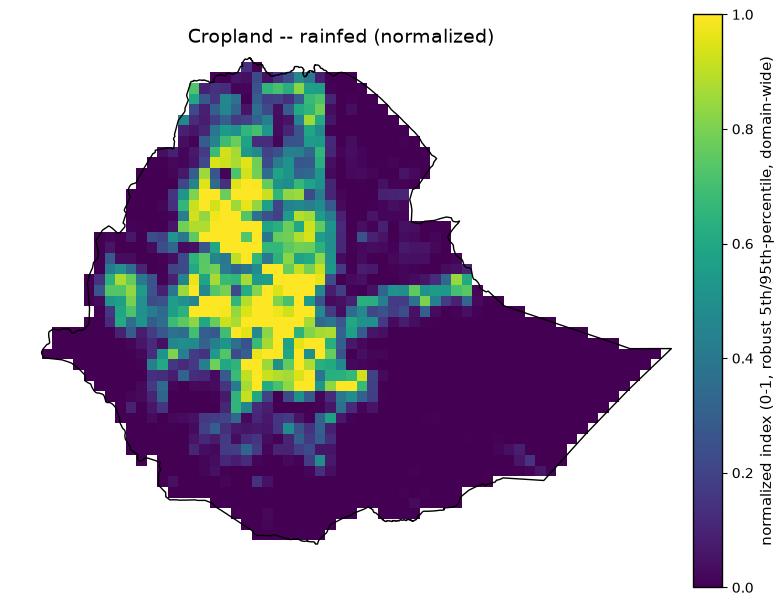

In [47]:
def plot_cropland_rainfed_normalized():
    """Plot Cropland -- rainfed (normalized) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='Cropland -- rainfed (normalized)',
        category='Exposure -- agriculture',
        source='Normalized from ethiopia_cropland_rainfed_absolute.tif',
        native_resolution='0.25 deg analysis grid',
        native_format='GeoTIFF',
        units='normalized index (0-1, robust 5th/95th-percentile, domain-wide)',
        processing='robust_percentile_normalize(p_low=5, p_high=95).',
        license='CC-BY 4.0',
    )
    describe_and_plot(exposure_dir / "ethiopia_cropland_rainfed_normalized.tif", meta)

plot_cropland_rainfed_normalized()

## Vulnerability composite indices -- outputs/vulnerability/

### V_drought (composite)

V_drought (composite)  (outputs/vulnerability/ethiopia_v_drought.tif)
  Category:          Vulnerability -- drought composite index
  Source:            Computed: 0.60 x drought_sensitivity + 0.40 x adaptive_capacity_deficit
  Native resolution: 0.25 deg analysis grid
  Native format:     GeoTIFF
  Units:             normalized index (0-1); higher = more vulnerable
  License:           Derived (see component layers above for source licenses)
  Processing:
    Sensitivity = 0.5 x poverty_rwi(inverted) + 0.5 x aridity(inverted); adaptive-capacity deficit = 0.5
    x irrigation(inverted) + 0.5 x electrification_no_access_rate (already deficit-framed). Static
    composite, not period-dependent. Domain mean 0.51, range 0.09-0.96.
  Clipped stats (Ethiopia boundary): n=1484/2820 valid (52.6% coverage), min=0.0918, mean=0.582, max=0.967


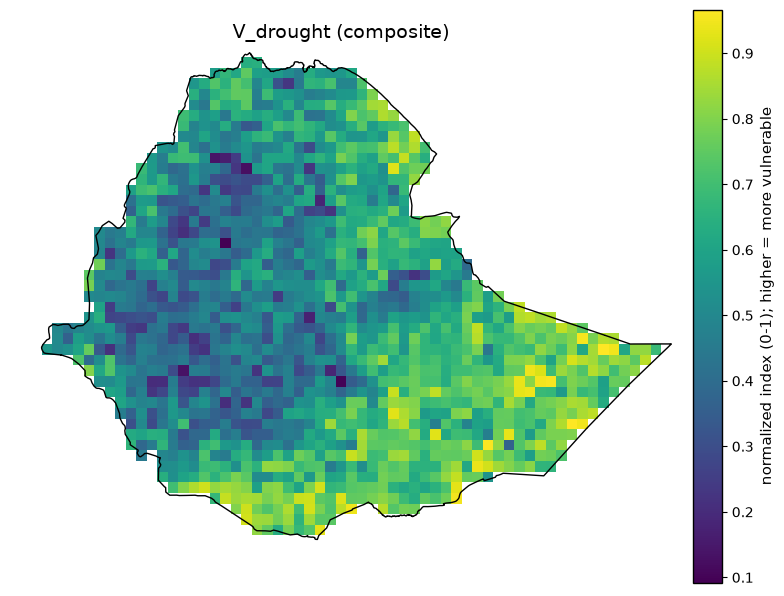

In [48]:
def plot_v_drought_composite():
    """Plot V_drought (composite) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='V_drought (composite)',
        category='Vulnerability -- drought composite index',
        source='Computed: 0.60 x drought_sensitivity + 0.40 x adaptive_capacity_deficit',
        native_resolution='0.25 deg analysis grid',
        native_format='GeoTIFF',
        units='normalized index (0-1); higher = more vulnerable',
        processing='Sensitivity = 0.5 x poverty_rwi(inverted) + 0.5 x aridity(inverted); adaptive-capacity deficit = 0.5 x irrigation(inverted) + 0.5 x electrification_no_access_rate (already deficit-framed). Static composite, not period-dependent. Domain mean 0.51, range 0.09-0.96.',
        license='Derived (see component layers above for source licenses)',
    )
    describe_and_plot(vulnerability_dir / "ethiopia_v_drought.tif", meta)

plot_v_drought_composite()

### V_wet (composite)

V_wet (composite)  (outputs/vulnerability/ethiopia_v_wet.tif)
  Category:          Vulnerability -- wet composite index
  Source:            Computed: 0.60 x wet_sensitivity + 0.40 x adaptive_capacity_deficit
  Native resolution: 0.25 deg analysis grid
  Native format:     GeoTIFF
  Units:             normalized index (0-1); higher = more vulnerable
  License:           Derived (see component layers above for source licenses)
  Processing:
    Sensitivity = poverty_rwi + elevation + slope + soil_clay + river_distance, each weighted 0.20 (all
    direction-corrected so higher = more vulnerable); adaptive-capacity deficit = 0.5 x
    healthsites(inverted) + 0.5 x electrification_no_access_rate. Domain mean 0.40, range 0.10-0.90.
    Correlation with V_drought is 0.641 (n=1485) -- moderate, genuine distinct signal, not a poverty
    proxy in disguise (fixed 2026-07-25 by adding real terrain/soil/river-proximity data).
  Clipped stats (Ethiopia boundary): n=1480/2820 valid (52.5% coverage)

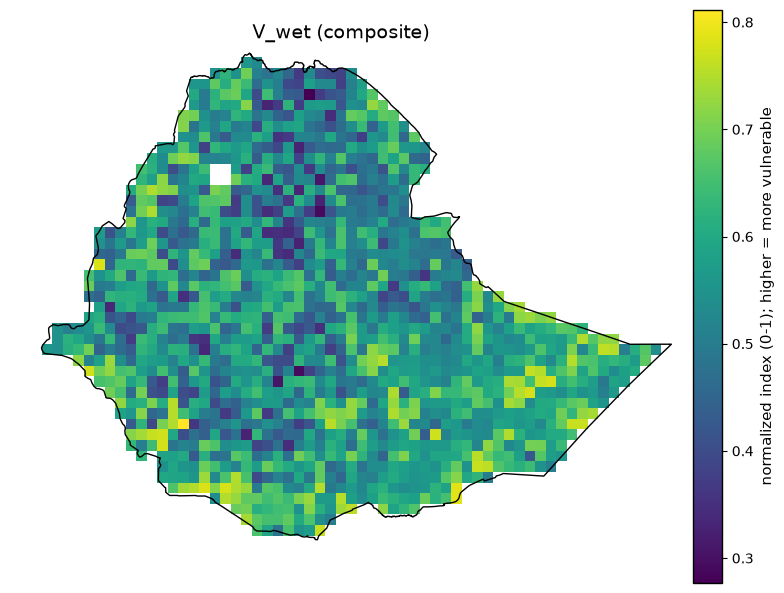

In [49]:
def plot_v_wet_composite():
    """Plot V_wet (composite) -- edit this function alone to change its metadata, colormap, or figure without touching any other layer."""
    meta = dict(
        title='V_wet (composite)',
        category='Vulnerability -- wet composite index',
        source='Computed: 0.60 x wet_sensitivity + 0.40 x adaptive_capacity_deficit',
        native_resolution='0.25 deg analysis grid',
        native_format='GeoTIFF',
        units='normalized index (0-1); higher = more vulnerable',
        processing='Sensitivity = poverty_rwi + elevation + slope + soil_clay + river_distance, each weighted 0.20 (all direction-corrected so higher = more vulnerable); adaptive-capacity deficit = 0.5 x healthsites(inverted) + 0.5 x electrification_no_access_rate. Domain mean 0.40, range 0.10-0.90. Correlation with V_drought is 0.641 (n=1485) -- moderate, genuine distinct signal, not a poverty proxy in disguise (fixed 2026-07-25 by adding real terrain/soil/river-proximity data).',
        license='Derived (see component layers above for source licenses)',
    )
    describe_and_plot(vulnerability_dir / "ethiopia_v_wet.tif", meta)

plot_v_wet_composite()